# Exercício Duelo de Modelos 4 — Titanic

## 1 Dinâmica da atividade

Nesta atividade, foi criado um duelo entre dois modelos de Machine Learning: SVM e XGBoost. A proposta segue a dinâmica apresentada nas aulas de Duelo de Modelos, utilizando a base Titanic para prever quais passageiros sobreviveram ao naufrágio.

Foram realizados três duelos:

- Duelo 1: modelos com pouco pré-processamento;
- Duelo 2: modelos com dados padronizados e balanceados;
- Duelo 3: modelos com ajuste de hiperparâmetros utilizando GridSearchCV.

Ao final, o melhor modelo foi utilizado para gerar o arquivo de submissão para o Kaggle.

## 2 Conhecendo os campeões

### 2.1 SVM

O SVM é um modelo de classificação que busca encontrar a melhor fronteira de decisão entre as classes. Ele é bastante eficiente em problemas onde existe uma separação clara entre os grupos, principalmente quando os dados são padronizados.

### 2.2 XGBoost

O XGBoost é um modelo baseado em árvores de decisão e utiliza o conceito de boosting. Ele constrói vários modelos sequenciais, em que cada novo modelo tenta corrigir os erros dos anteriores, tornando-o bastante poderoso para problemas de classificação.

## 3 Arena do duelo: base Titanic

A base Titanic foi utilizada como arena do duelo. O objetivo é prever se um passageiro sobreviveu ou não, com base em variáveis como sexo, idade, classe do bilhete, tarifa, cabine e local de embarque.

## 4 Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.svm import SVC
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 5 Carregamento dos dados

In [2]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [3]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test_df.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## 6 Tratamento inicial dos dados

In [5]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
# Verificando valores nulos na base de teste
test_df.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [8]:
# Criando variável indicando se a cabine era conhecida
train_df['Cabin_known'] = train_df['Cabin'].notna().astype(int)
test_df['Cabin_known'] = test_df['Cabin'].notna().astype(int)

In [9]:
# Preenchendo valores nulos de Age com a mediana da base de treino
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
test_df['Age'] = test_df['Age'].fillna(train_df['Age'].median())

In [10]:
# Preenchendo valores nulos de Embarked com a moda da base de treino
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])
test_df['Embarked'] = test_df['Embarked'].fillna(train_df['Embarked'].mode()[0])

In [11]:
# Preenchendo valor nulo de Fare no teste com a mediana da base de treino
test_df['Fare'] = test_df['Fare'].fillna(train_df['Fare'].median())

In [12]:
# Preenchendo Cabin com "Unknown", pois há muitos valores ausentes
train_df['Cabin'] = train_df['Cabin'].fillna('Unknown')
test_df['Cabin'] = test_df['Cabin'].fillna('Unknown')

In [13]:
train_df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
Cabin_known    0
dtype: int64

In [14]:
test_df.isnull().sum()

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
Cabin_known    0
dtype: int64

Após a verificação dos valores ausentes, foram realizados alguns tratamentos. A variável `Age` foi preenchida com a mediana, pois é uma medida menos sensível a valores extremos. A variável `Embarked` foi preenchida com a moda, por ser categórica. A variável `Fare`, que possui valor ausente na base de teste, também foi preenchida com a mediana da base de treino.

Como a variável `Cabin` possui muitos valores ausentes, foi criada a variável `Cabin_known`, indicando se a cabine era conhecida ou não. Em seguida, os valores ausentes de `Cabin` foram preenchidos como `Unknown`.

## 7 Análise da variável alvo

In [15]:
train_df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

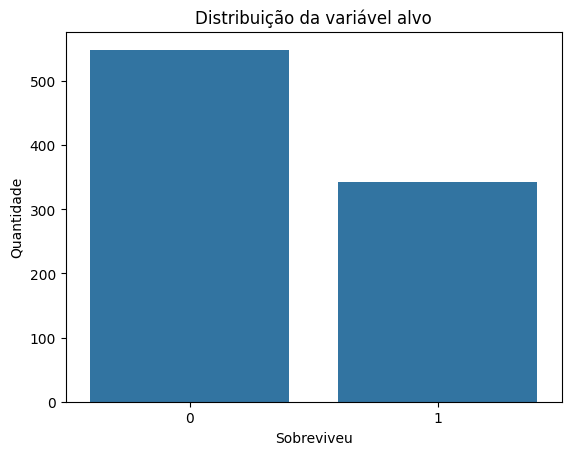

In [16]:
sns.countplot(data=train_df, x='Survived')
plt.title('Distribuição da variável alvo')
plt.xlabel('Sobreviveu')
plt.ylabel('Quantidade')
plt.show()

A variável alvo `Survived` indica se o passageiro sobreviveu ou não ao naufrágio. Observa-se que há mais passageiros que não sobreviveram do que passageiros sobreviventes, indicando um certo desbalanceamento entre as classes. Por isso, nas próximas etapas será aplicado balanceamento com SMOTE, seguindo a abordagem vista nas aulas.

## 8 Duelo 1 - Pouco pré-processamento

In [17]:
# Criando cópias das bases para o Duelo 1
train_d1 = train_df.copy()
test_d1 = test_df.copy()

In [18]:
# Transformando a variável Sex em numérica
train_d1['Sex'] = train_d1['Sex'].map({'male': 0, 'female': 1})
test_d1['Sex'] = test_d1['Sex'].map({'male': 0, 'female': 1})

In [19]:
# Selecionando poucas variáveis para o primeiro duelo
variaveis_d1 = ['Sex', 'Cabin_known', 'Fare', 'Pclass']

X_d1 = train_d1[variaveis_d1]
y = train_d1['Survived']

X_test_d1 = test_d1[variaveis_d1]

In [20]:
# Separando os dados em treino e validação
X_train_d1, X_valid_d1, y_train, y_valid = train_test_split(
    X_d1,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
# Função para avaliar os modelos
def avaliar_modelo(nome_modelo, y_real, y_pred):
    acc = accuracy_score(y_real, y_pred)
    print(nome_modelo)
    print(f'Acurácia: {acc:.4f}')
    print('\nRelatório de classificação:')
    print(classification_report(y_real, y_pred))
    return acc

In [22]:
xgboost_duelo1 = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgboost_duelo1.fit(X_train_d1, y_train)

y_pred_xgb_d1 = xgboost_duelo1.predict(X_valid_d1)

acc_xgb_d1 = avaliar_modelo(
    'XGBoost - Duelo 1',
    y_valid,
    y_pred_xgb_d1
)

XGBoost - Duelo 1
Acurácia: 0.7318

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78       110
           1       0.65      0.65      0.65        69

    accuracy                           0.73       179
   macro avg       0.72      0.72      0.72       179
weighted avg       0.73      0.73      0.73       179



In [23]:
scaler_d1 = StandardScaler()

X_train_d1_scaled = scaler_d1.fit_transform(X_train_d1)
X_valid_d1_scaled = scaler_d1.transform(X_valid_d1)

In [24]:
svm_duelo1 = SVC(
    kernel='linear',
    C=1.0,
    random_state=42
)

svm_duelo1.fit(X_train_d1_scaled, y_train)

y_pred_svm_d1 = svm_duelo1.predict(X_valid_d1_scaled)

acc_svm_d1 = avaliar_modelo(
    'SVM - Duelo 1',
    y_valid,
    y_pred_svm_d1
)

SVM - Duelo 1
Acurácia: 0.7765

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.80      0.85      0.82       110
           1       0.74      0.65      0.69        69

    accuracy                           0.78       179
   macro avg       0.77      0.75      0.76       179
weighted avg       0.77      0.78      0.77       179



No primeiro duelo, os modelos SVM e XGBoost foram treinados com poucas variáveis e um pré-processamento simples. Essa etapa funciona como uma linha de base para comparar o desempenho inicial dos modelos antes da aplicação de técnicas mais avançadas, como balanceamento, padronização completa e ajuste de hiperparâmetros.

## 9 Duelo 2 - Padronização e balanceamento

In [25]:
# Criando cópias das bases para o Duelo 2
train_d2 = train_df.copy()
test_d2 = test_df.copy()

In [26]:
# Criando novas variáveis para melhorar o desempenho dos modelos
def criar_variaveis(df):
    df = df.copy()
    
    # Tamanho da família a bordo
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    
    # Indica se o passageiro viajava sozinho
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    
    # Extraindo o título do nome
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    
    # Agrupando títulos menos frequentes
    df['Title'] = df['Title'].replace(
        ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major',
         'Rev', 'Sir', 'Jonkheer', 'Dona'],
        'Rare'
    )
    
    df['Title'] = df['Title'].replace({
        'Mlle': 'Miss',
        'Ms': 'Miss',
        'Mme': 'Mrs'
    })
    
    # Extraindo o deck da cabine
    df['CabinDeck'] = df['Cabin'].astype(str).str[0]
    
    return df

In [27]:
train_d2 = criar_variaveis(train_d2)
test_d2 = criar_variaveis(test_d2)

In [28]:
# Transformando Sex em variável numérica
train_d2['Sex'] = train_d2['Sex'].map({'male': 0, 'female': 1})
test_d2['Sex'] = test_d2['Sex'].map({'male': 0, 'female': 1})

In [29]:
# Aplicando One-Hot Encoding nas variáveis categóricas
train_d2 = pd.get_dummies(
    train_d2,
    columns=['Embarked', 'Title', 'CabinDeck'],
    drop_first=True
)

test_d2 = pd.get_dummies(
    test_d2,
    columns=['Embarked', 'Title', 'CabinDeck'],
    drop_first=True
)

In [30]:
# Separando variáveis explicativas e variável alvo
X_d2 = train_d2.drop(
    columns=['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin']
)

y_d2 = train_d2['Survived']

X_test_d2 = test_d2.drop(
    columns=['PassengerId', 'Name', 'Ticket', 'Cabin']
)

In [31]:
# Garantindo que treino e teste tenham as mesmas colunas
X_d2, X_test_d2 = X_d2.align(
    X_test_d2,
    join='left',
    axis=1,
    fill_value=0
)

In [32]:
# Separando os dados em treino e validação
X_train_d2, X_valid_d2, y_train_d2, y_valid_d2 = train_test_split(
    X_d2,
    y_d2,
    test_size=0.2,
    random_state=42,
    stratify=y_d2
)

In [33]:
# Padronizando os dados
scaler_d2 = StandardScaler()

X_train_d2_scaled = scaler_d2.fit_transform(X_train_d2)
X_valid_d2_scaled = scaler_d2.transform(X_valid_d2)
X_test_d2_scaled = scaler_d2.transform(X_test_d2)

In [34]:
# Aplicando SMOTE apenas nos dados de treino
smote = SMOTE(random_state=42)

X_train_d2_balanced, y_train_d2_balanced = smote.fit_resample(
    X_train_d2_scaled,
    y_train_d2
)

In [35]:
print('Distribuição das classes antes do balanceamento:')
print(y_train_d2.value_counts())

print('\nDistribuição das classes depois do balanceamento:')
print(pd.Series(y_train_d2_balanced).value_counts())

Distribuição das classes antes do balanceamento:
Survived
0    439
1    273
Name: count, dtype: int64

Distribuição das classes depois do balanceamento:
Survived
1    439
0    439
Name: count, dtype: int64


### 9.1 XGBoost - Duelo 2

In [36]:
xgboost_duelo2 = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgboost_duelo2.fit(X_train_d2_balanced, y_train_d2_balanced)

y_pred_xgb_d2 = xgboost_duelo2.predict(X_valid_d2_scaled)

acc_xgb_d2 = avaliar_modelo(
    'XGBoost - Duelo 2',
    y_valid_d2,
    y_pred_xgb_d2
)

XGBoost - Duelo 2
Acurácia: 0.7989

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.84      0.83      0.83       110
           1       0.73      0.75      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



### 9.2 SVM - Duelo 2

In [37]:
svm_duelo2 = SVC(
    kernel='linear',
    C=1.0,
    random_state=42
)

svm_duelo2.fit(X_train_d2_balanced, y_train_d2_balanced)

y_pred_svm_d2 = svm_duelo2.predict(X_valid_d2_scaled)

acc_svm_d2 = avaliar_modelo(
    'SVM - Duelo 2',
    y_valid_d2,
    y_pred_svm_d2
)

SVM - Duelo 2
Acurácia: 0.8268

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       110
           1       0.78      0.77      0.77        69

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



No segundo duelo, foram aplicadas melhorias no pré-processamento dos dados, incluindo a criação de novas variáveis, transformação de variáveis categóricas, padronização e balanceamento com SMOTE. Essas etapas ajudam principalmente o SVM, que é sensível à escala das variáveis, e também contribuem para reduzir o impacto do desbalanceamento entre as classes.

## 10 Duelo 3 - GridSearchCV

### 10.1 XGBoost - Duelo 3

In [38]:
# Definindo os parâmetros para o XGBoost
param_grid_xgb = {
    'max_depth': [3, 5, 7],
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [39]:
# Criando o modelo base
xgboost_duelo3 = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [40]:
# Aplicando GridSearchCV no XGBoost
grid_search_xgb = GridSearchCV(
    estimator=xgboost_duelo3,
    param_grid=param_grid_xgb,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search_xgb.fit(X_train_d2_balanced, y_train_d2_balanced)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fol

In [41]:
# Melhor modelo e melhores parâmetros
print('Melhores parâmetros do XGBoost:')
print(grid_search_xgb.best_params_)

print(f'Melhor acurácia média do XGBoost: {grid_search_xgb.best_score_:.4f}')

Melhores parâmetros do XGBoost:
{'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 50, 'subsample': 0.8}
Melhor acurácia média do XGBoost: 0.8406


In [42]:
# Avaliando o melhor XGBoost na base de validação
best_xgb = grid_search_xgb.best_estimator_

y_pred_xgb_d3 = best_xgb.predict(X_valid_d2_scaled)

acc_xgb_d3 = avaliar_modelo(
    'XGBoost - Duelo 3',
    y_valid_d2,
    y_pred_xgb_d3
)

XGBoost - Duelo 3
Acurácia: 0.8045

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       110
           1       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



### 10.2 SVM - Duelo 3

In [43]:
# Definindo os parâmetros para o SVM
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

In [44]:
# Criando o modelo base
svm_duelo3 = SVC(
    random_state=42
)

In [45]:
# Aplicando GridSearchCV no SVM
grid_search_svm = GridSearchCV(
    estimator=svm_duelo3,
    param_grid=param_grid_svm,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search_svm.fit(X_train_d2_balanced, y_train_d2_balanced)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also d

In [46]:
# Melhor modelo e melhores parâmetros
print('Melhores parâmetros do SVM:')
print(grid_search_svm.best_params_)

print(f'Melhor acurácia média do SVM: {grid_search_svm.best_score_:.4f}')

Melhores parâmetros do SVM:
{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Melhor acurácia média do SVM: 0.8337


In [47]:
# Avaliando o melhor SVM na base de validação
best_svm = grid_search_svm.best_estimator_

y_pred_svm_d3 = best_svm.predict(X_valid_d2_scaled)

acc_svm_d3 = avaliar_modelo(
    'SVM - Duelo 3',
    y_valid_d2,
    y_pred_svm_d3
)

SVM - Duelo 3
Acurácia: 0.7654

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       110
           1       0.71      0.67      0.69        69

    accuracy                           0.77       179
   macro avg       0.75      0.75      0.75       179
weighted avg       0.76      0.77      0.76       179



No terceiro duelo, foi utilizado o GridSearchCV para buscar melhores combinações de hiperparâmetros para os modelos SVM e XGBoost. Essa etapa permite testar diferentes configurações de forma automática, utilizando validação cruzada para avaliar o desempenho médio dos modelos em diferentes divisões dos dados.

Essa abordagem torna a escolha dos parâmetros mais robusta e reduz a dependência de uma configuração escolhida manualmente.

## 11 Comparação dos resultados

In [48]:
resultados = pd.DataFrame({
    'Modelo': [
        'XGBoost - Duelo 1',
        'SVM - Duelo 1',
        'XGBoost - Duelo 2',
        'SVM - Duelo 2',
        'XGBoost - Duelo 3',
        'SVM - Duelo 3'
    ],
    'Acuracia_validacao': [
        acc_xgb_d1,
        acc_svm_d1,
        acc_xgb_d2,
        acc_svm_d2,
        acc_xgb_d3,
        acc_svm_d3
    ]
})

resultados.sort_values(by='Acuracia_validacao', ascending=False)

,Modelo,Acuracia_validacao
3,SVM - Duelo 2,0.826816
4,XGBoost - Duelo 3,0.804469
2,XGBoost - Duelo 2,0.798883
1,SVM - Duelo 1,0.776536
5,SVM - Duelo 3,0.765363
0,XGBoost - Duelo 1,0.731844


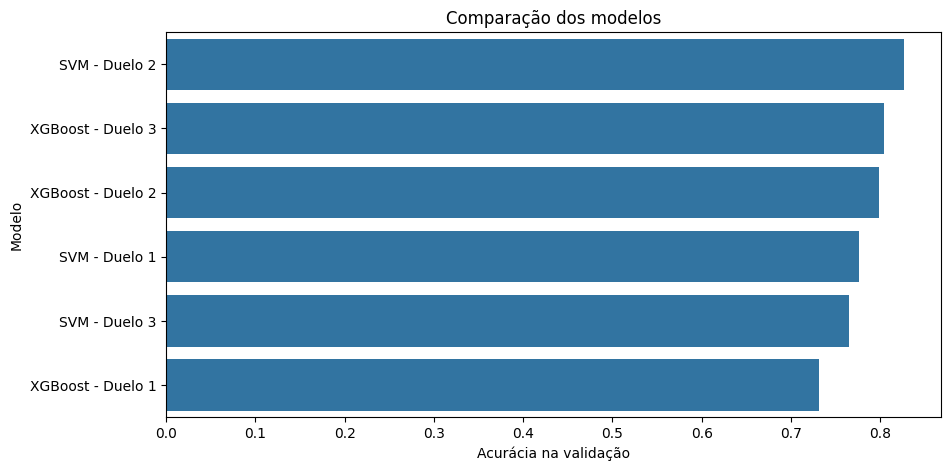

In [49]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=resultados.sort_values(by='Acuracia_validacao', ascending=False),
    x='Acuracia_validacao',
    y='Modelo'
)

plt.title('Comparação dos modelos')
plt.xlabel('Acurácia na validação')
plt.ylabel('Modelo')
plt.show()

In [50]:
melhor_resultado = resultados.sort_values(
    by='Acuracia_validacao',
    ascending=False
).iloc[0]

melhor_resultado

Modelo                SVM - Duelo 2
Acuracia_validacao         0.826816
Name: 3, dtype: object

A comparação dos resultados mostra que o modelo SVM no Duelo 2 apresentou o melhor desempenho na base de validação. Esse resultado indica que a combinação entre criação de novas variáveis, padronização dos dados e balanceamento com SMOTE contribuiu positivamente para o desempenho do modelo.

Apesar do GridSearchCV ter melhorado o XGBoost em relação aos duelos anteriores, o SVM com pré-processamento e balanceamento ainda apresentou a maior acurácia na validação.

## 12 Geração do arquivo para o Kaggle

In [51]:
# Padronizando toda a base de treino e a base de teste
scaler_final = StandardScaler()

X_d2_scaled_final = scaler_final.fit_transform(X_d2)
X_test_d2_scaled_final = scaler_final.transform(X_test_d2)

In [52]:
# Aplicando SMOTE na base completa de treino
smote_final = SMOTE(random_state=42)

X_d2_balanced_final, y_d2_balanced_final = smote_final.fit_resample(
    X_d2_scaled_final,
    y_d2
)

In [53]:
# Treinando o melhor modelo encontrado: SVM - Duelo 2
modelo_final = SVC(
    kernel='linear',
    C=1.0,
    random_state=42
)

modelo_final.fit(X_d2_balanced_final, y_d2_balanced_final)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [54]:
# Gerando previsões para a base de teste
predicoes = modelo_final.predict(X_test_d2_scaled_final)

In [55]:
# Criando arquivo de submissão para o Kaggle
submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived': predicoes
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [56]:
submission.to_csv('submission.csv', index=False)

print('Arquivo submission.csv criado com sucesso!')

Arquivo submission.csv criado com sucesso!


Após a comparação dos modelos, o SVM do Duelo 2 foi escolhido como modelo final por apresentar a maior acurácia na base de validação. O modelo foi treinado novamente utilizando toda a base de treino, com padronização e balanceamento, e em seguida foi utilizado para gerar as previsões da base de teste do Kaggle.

In [57]:
submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


## 13 Resultado no Kaggle

O arquivo `submission.csv` foi enviado na competição Titanic do Kaggle e obteve **Public Score de 0.75598**.

In [58]:
submission.to_csv('submission.csv', index=False)

![Resultado no Kaggle](kaggle_score.png)

## 15 Conclusão

Nesta atividade, foi desenvolvido um duelo entre os modelos SVM e XGBoost utilizando a base Titanic. Seguindo a proposta das aulas, os modelos foram comparados em três cenários: o primeiro com pouco pré-processamento, o segundo com criação de novas variáveis, padronização e balanceamento com SMOTE, e o terceiro com ajuste de hiperparâmetros utilizando GridSearchCV.

Os resultados mostraram que o pré-processamento teve grande impacto no desempenho dos modelos. O SVM apresentou o melhor resultado no Duelo 2, alcançando a maior acurácia na base de validação. Esse desempenho pode ser explicado pelo uso da padronização, que é importante para modelos baseados em margem, e pelo balanceamento das classes com SMOTE.

Ao final, o melhor modelo foi treinado com toda a base de treino e utilizado para gerar o arquivo `submission.csv`, que pode ser enviado para avaliação na competição Titanic do Kaggle.